In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.8/644.8 kB 11.6 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="AHaJH1doEBFqOCf6gQfQ")
project = rf.workspace("computer-vision-m75wg").project("fetal-brain-abnormality-classification")
dataset = project.version(2).download("yolov8")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 22.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 MB 13.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 8.3 MB/s eta 0:00:00
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 3.1.1
    Uninstalling pyparsing-3.1.1:
      Successfully uninstalled pyparsing-3.1.1
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.8.1.78
    Uninstalling opencv-python-headless-4.8.1.78:
      Successfully uninsta

loading Roboflow workspace...
loading Roboflow project...
Dependency ultralytics==8.0.134 is required but found version=8.0.203, to fix: `pip install ultralytics==8.0.134`



Extracting Dataset Version Zip to Fetal-brain-abnormality-classification-2 in yolov8:: 100%|██████████| 2794/2794 [00:00<00:00, 8787.60it/s]


In [ ]:
from ultralytics import YOLO

In [ ]:
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=100 imgsz=640

Ultralytics YOLOv8.0.203 🚀 Python-3.10.12 torch-2.1.0+cu118 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/Fetal-brain-abnormality-classification-2/data.yaml, epochs=100, patience=50, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, stream_buffer=False, line_width=None, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, boxes=True, fo

In [ ]:
!yolo task=detect \
mode=predict \
model=/content/runs/detect/train2/weights/best.pt \
conf=0.25 \
source={dataset.location}/test/images

Ultralytics YOLOv8.0.203 🚀 Python-3.10.12 torch-2.1.0+cu118 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 11131002 parameters, 0 gradients, 28.5 GFLOPs

image 1/60 /content/Fetal-brain-abnormality-classification-2/test/images/anold-chiari-maformation-26b_aug_2_png_jpg.rf.22f8b3b1cf3a559211df3b32f818ed0f.jpg: 640x640 1 anold chiari malformation, 16.3ms
image 2/60 /content/Fetal-brain-abnormality-classification-2/test/images/anold-chiari-maformation-26b_aug_3_png_jpg.rf.2d1696c7a9491558d58d78cb96d1cda2.jpg: 640x640 1 anold chiari malformation, 16.5ms
image 3/60 /content/Fetal-brain-abnormality-classification-2/test/images/anold-chiari-malformation-21a_aug_4_png_jpg.rf.006238f013f136c79f6ce9fdeb892e92.jpg: 640x640 1 anold chiari malformation, 16.2ms
image 4/60 /content/Fetal-brain-abnormality-classification-2/test/images/anold-chiari-malformation-21a_aug_5_png_jpg.rf.7caf35ca9b5c11253b242500d71c551d.jpg: 640x640 1 anold chiari malformation, 16.2ms
image 5/60 /content/Feta

In [ ]:
import glob
import matplotlib.pyplot as plt

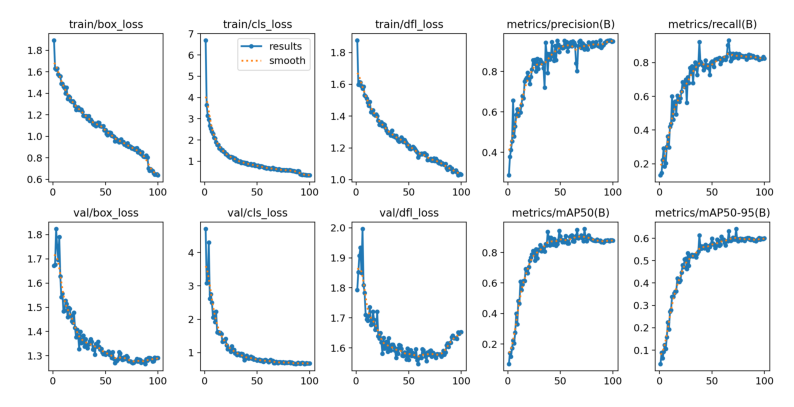

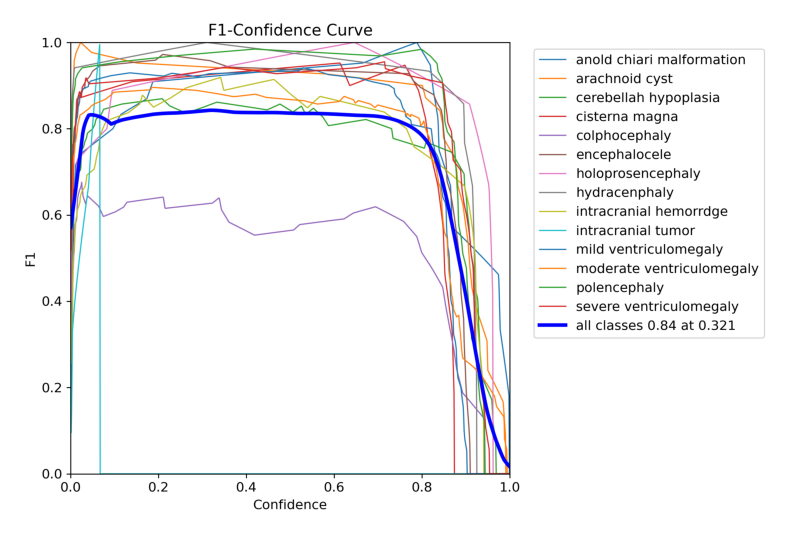

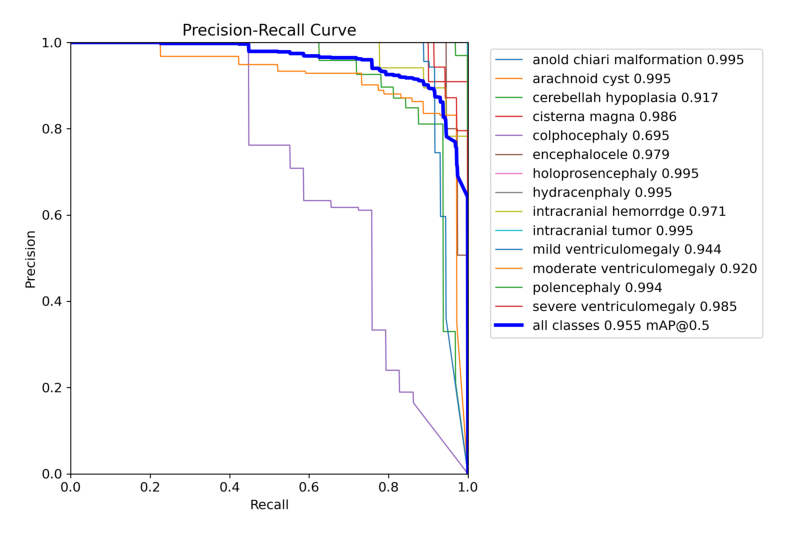

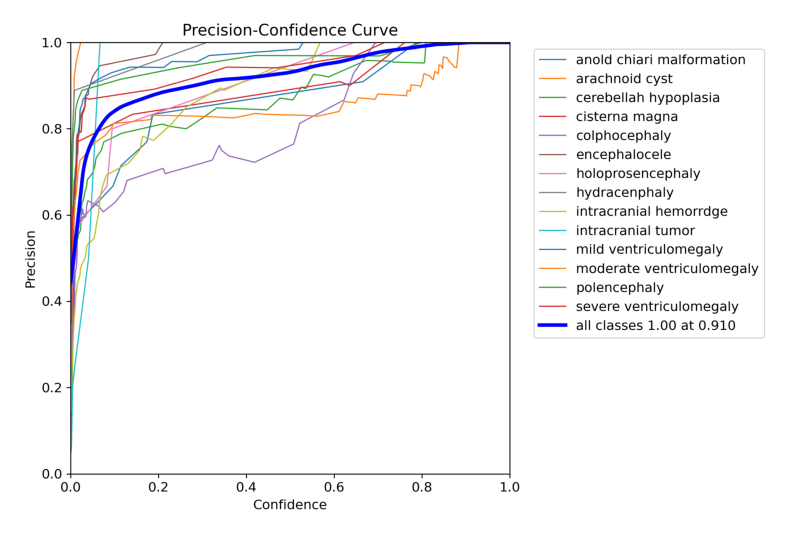

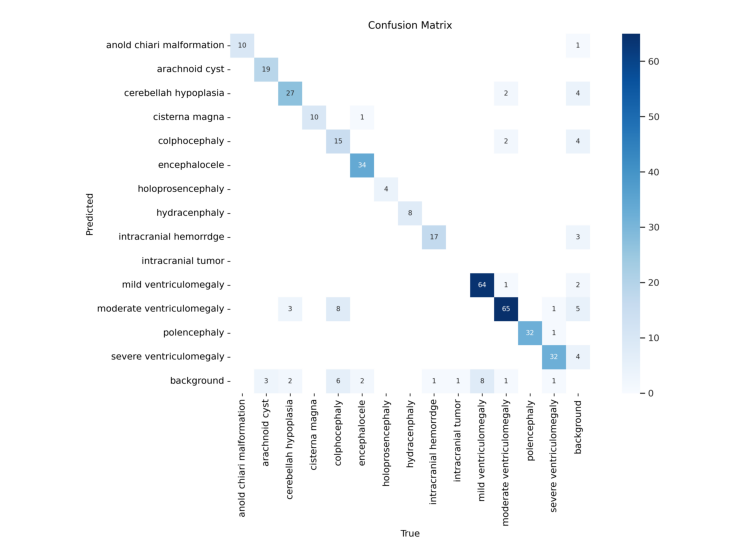

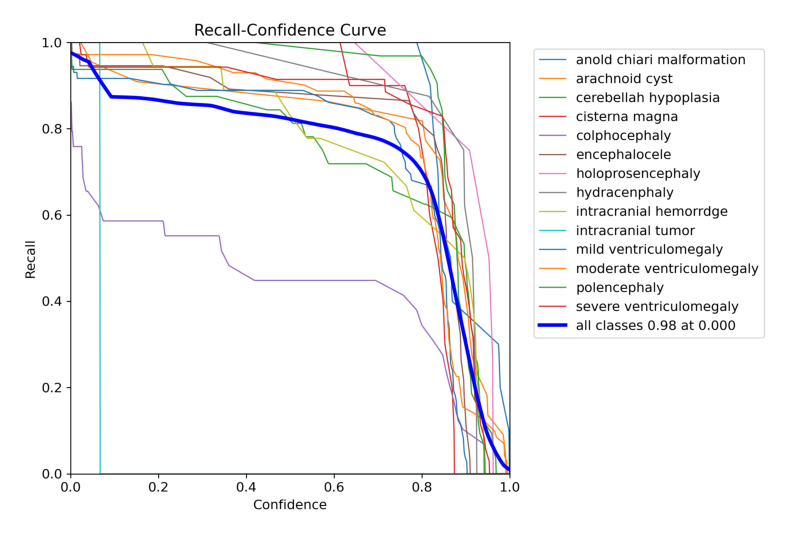

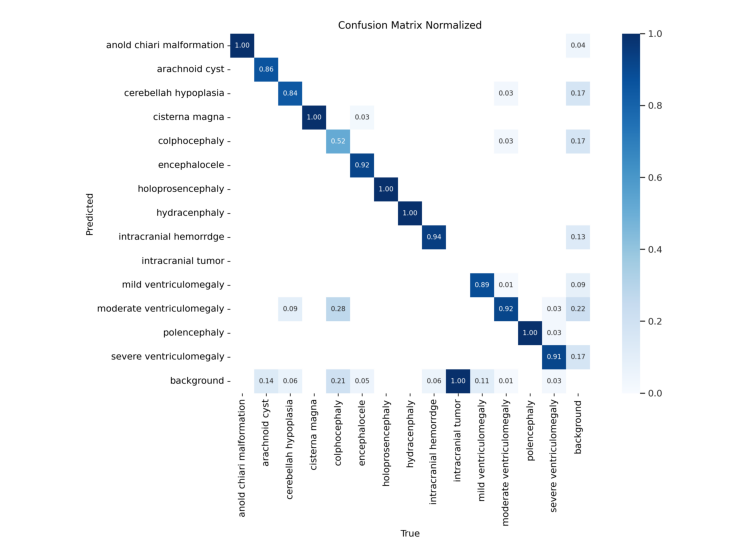

In [ ]:
results_dir_path = '/content/runs/detect/train2'
images = glob.glob(f"{results_dir_path}/*.png")

for i in range(7):
    plt.figure(figsize=(10, 7))
    image = plt.imread(images[i])
    plt.imshow(image)
    plt.axis('off')
    plt.show()

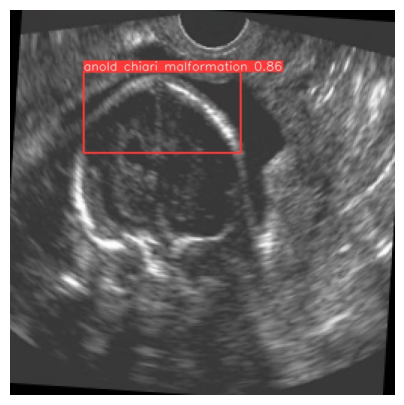

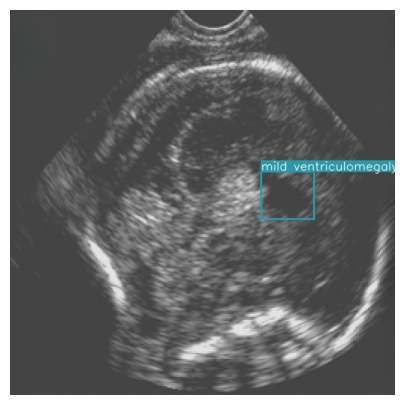

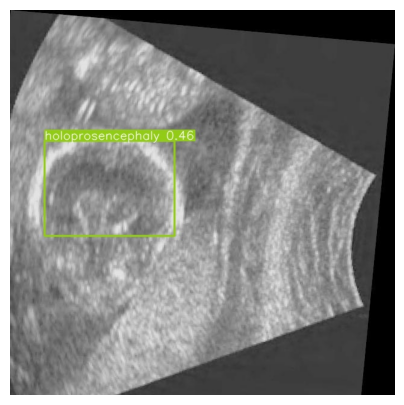

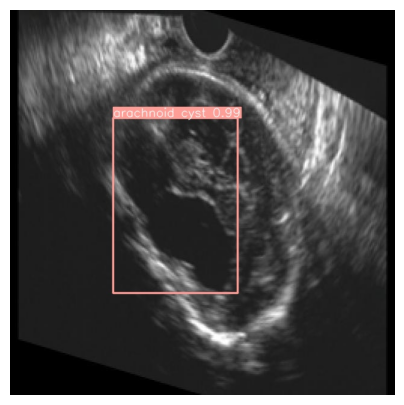

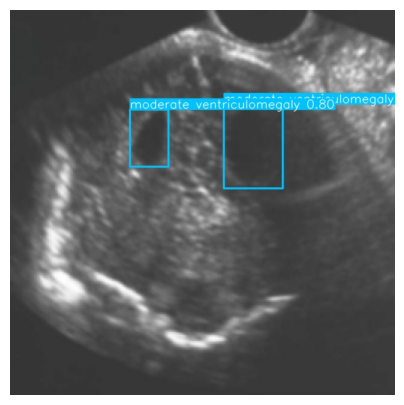

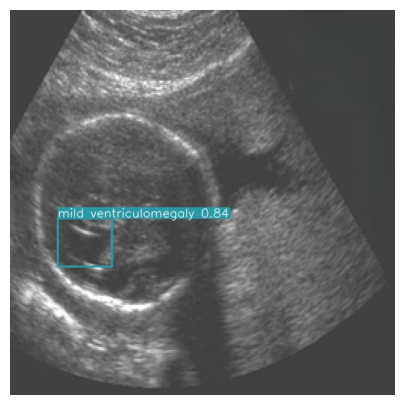

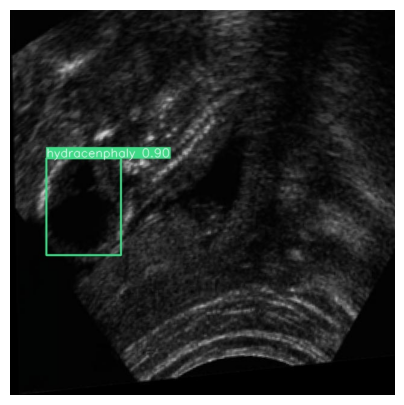

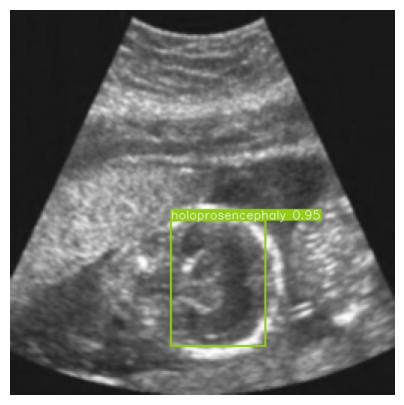

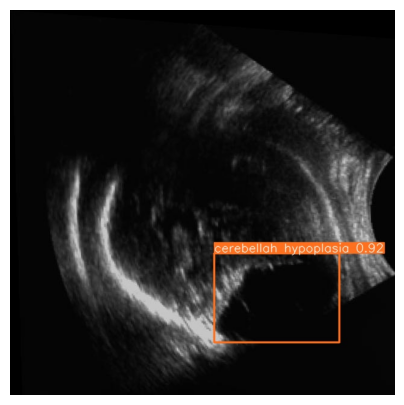

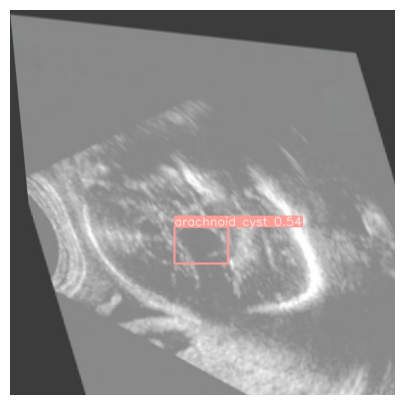

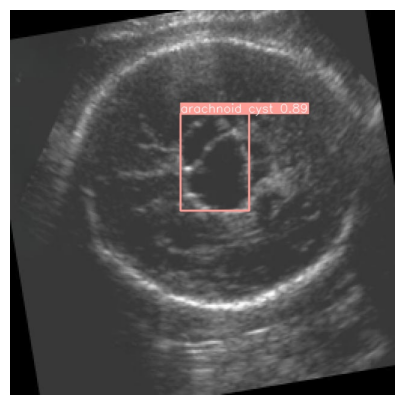

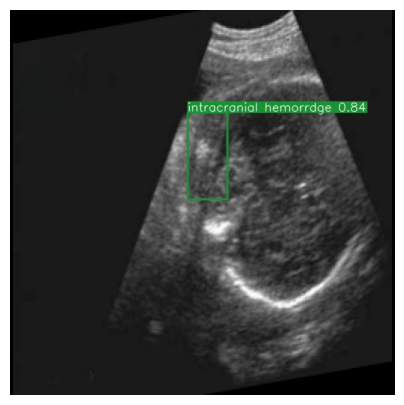

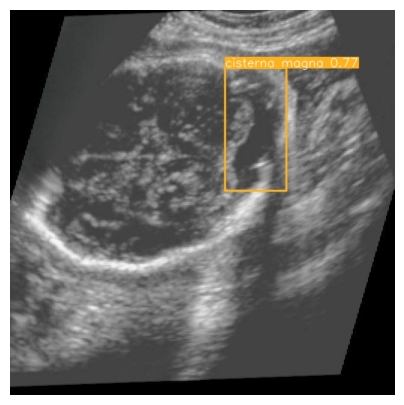

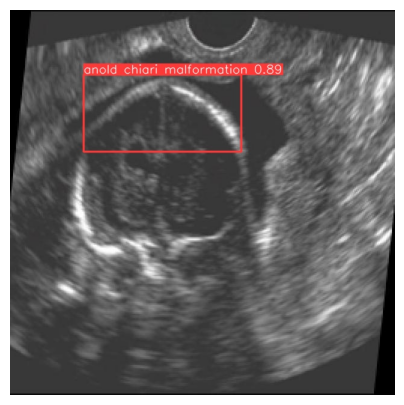

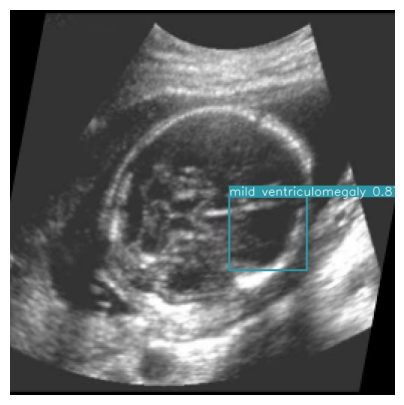

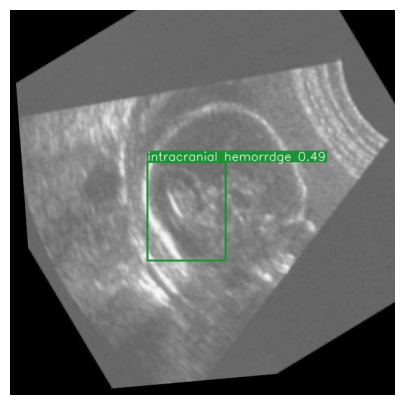

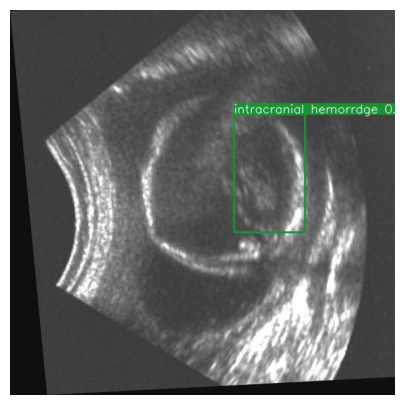

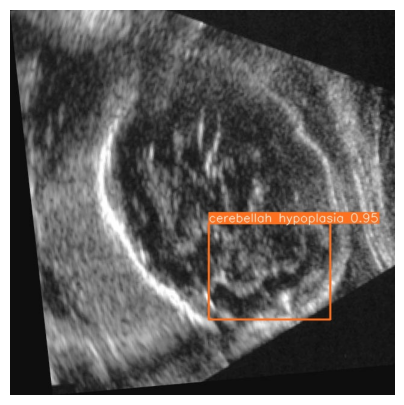

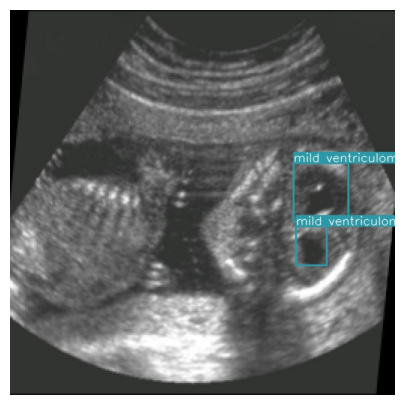

In [ ]:
results_dir_path = '/content/runs/detect/predict'
images = glob.glob(f"{results_dir_path}/*.jpg")

for i in range(21,40):
    plt.figure(figsize=(5, 5))
    image = plt.imread(images[i])
    plt.imshow(image)
    plt.axis('off')
    plt.show()